In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xmf6
import flopy
from denit import gwf, gwt, plot, utils
linea = 50*chr(0x2015)

In [57]:
# --- DEFINICIÓN DE LAS RUTAS Y NOMBRES ---
#
paths = dict(
    # Ejecutable de Modflow: WINDOWS
    mf6_exe = r"C:\Users\luiggi\Documents\GitSites\mf6_tutorial\mf6\windows\mf6",
    mf6_dll = r"C:\Users\luiggi\Documents\GitSites\mf6_tutorial\mf6\windows\libmf6.dll",
    #
    # Nombre de los modelos y espacios de trabajo
    flow_name = "flow",
    flow_ws = "mf6_gwf_gwt_comp",
    tran_name = "transport",
    tran_ws = "mf6_gwf_gwt_comp",
    #
    # Nombre de los archivos de datos
    u_init = "u_init.dat",
)
#
# --- DEFINIENDO CONDICIONES INICIALES ---
#
print(linea)
print("Generating initial conditions".center(50))
components, species = utils.initial_conditions(paths, comp = True, spec = True)
ncomp = len(components["names"])
print(linea)
#
xmf6.nice_print(paths, "Paths and filenames")
#
# --- DATOS PARA LA SIMULACIÓN ---
#
# Paso del tiempo
dt = 1.0e-2
NT = 1
#
# Discretización del espacio
nlay, nrow, ncol = 1, 1, 10
delr, delc, delz = 0.1, 1.0, 1.0 
dis = {
    'length_units' : "meters",
    'nlay': nlay, 
    'nrow': nrow, 
    'ncol': ncol,
    'delr': delr, 
    'delc': delc, 
    'top' : delz, 
    'botm': 0.0 
}
xmf6.nice_print(dis, "Spatial discretization")
#
# Parámetros físicos.
phys = dict(
    perioddata = [(1, 500, 1.0)], #PERLEN, NSTP, TSMULT
    porosity = 0.5,  # Porosity of mobile domain (unitless)
    hydraulic_conductivity = 1.0,  # Hydraulic conductivity ($cm s^{-1}$)
    inflow = 0.2,  # Specific discharge ($cm s^{-1}$)
    longitudinal_dispersivity = 1.0,# 0.5,
    retardation_factor = 1.0, 
    components = components["names"], # Components names
    source_concentration = components["ext_water"],  # Source concentration (unitless)
    initial_concentration = components["init_conc"], # Initial concentration (unitless)
    species = species["names"], # Components names
    s_source_concentration = species["ext_water"],  # Species Source concentration (unitless)
    s_initial_concentration = species["init_conc"], # Species Initial concentration (unitless)
)
xmf6.nice_print(phys, "Physical parameters")

――――――――――――――――――――――――――――――――――――――――――――――――――
          Generating initial conditions           
――――――――――――――――――――――――――――――――――――――――――――――――――

Paths and filenames
―――――――――――――――――――
  mf6_exe = C:\Users\luiggi\Documents\GitSites\mf6_tutorial\mf6\windows\mf6
  mf6_dll = C:\Users\luiggi\Documents\GitSites\mf6_tutorial\mf6\windows\libmf6.dll
flow_name = flow
  flow_ws = mf6_gwf_gwt_comp
tran_name = transport
  tran_ws = mf6_gwf_gwt_comp
   u_init = u_init.dat
―――――――――――――――――――

Spatial discretization
――――――――――――――――――――――
length_units = meters
        nlay = 1
        nrow = 1
        ncol = 10
        delr = 0.1
        delc = 1.0
         top = 1.0
        botm = 0.0
――――――――――――――――――――――

Physical parameters
―――――――――――――――――――
               perioddata = ―― data array ――
                          = (1, 500, 1.0)
                 porosity = 0.5
   hydraulic_conductivity = 1.0
                   inflow = 0.2
longitudinal_dispersivity = 1.0
       retardation_factor = 1.0

In [62]:
m=0
#
# - SIMULACION DEL FLUJO CON GWF ---
#
# --- Construcción de la simulación de flujo
phys["perioddata"] = [(1, 1, 1.0)] #PERLEN, NSTP, TSMULT
phys["s_source_concentration"][m] = species["ext_water"][m] * 100
print(phys["s_source_concentration"][m] )
o_sim_f = gwf.build(phys, dis, m, paths)
#
# --- Ejecución de la simulación ---
print(" GWF", end = "")
o_sim_f.run_simulation(silent=True)
#
# - SIMULACIÓN DE TRANSPORTE CON GWT PARA CADA COMPONENTE
#
# --- Construcción de la simulación de transporte
phys["perioddata"] = [(5, 500, 1.0)] #PERLEN, NSTP, TSMULT
o_sim_t = gwt.build(phys, dis, m, paths)
#
# --- Ejecución de la simulación de transporte ---
print(f"-GWT: C{m+1}: {species["names"][m]}", end= " |")
o_sim_t.run_simulation(silent=True)

9.999999999999999e-06
 GWF-GWT: C1: h+ |

(True, [])

times = 500
q : [0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2]
Inflow: 1.00e-05
IC: [1.e-07 1.e-07 1.e-07 1.e-07 1.e-07 1.e-07 1.e-07 1.e-07 1.e-07 1.e-07]


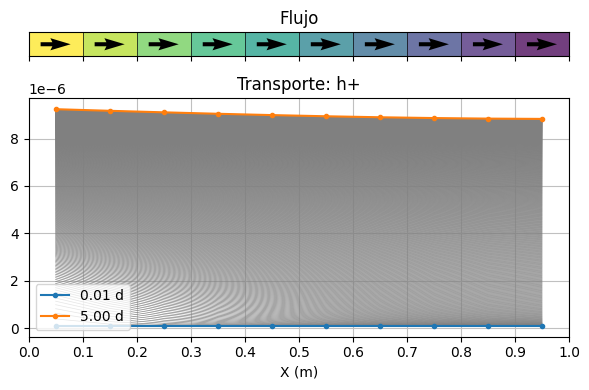

In [63]:
grb = flopy.mf6.utils.MfGrdFile("mf6_gwf_gwt_comp/flow.dis.grb", verbose=False)
grid = grb.modelgrid
x = grid.xycenters[0]
y = grid.ycellcenters[0]
xv = grid.xyzvertices[0][0]
xmin = grid.xvertices[0][0]
xmax = grid.xvertices[0][-1]

hds = flopy.utils.HeadFile("mf6_gwf_gwt_comp/flow.hds")
head = hds.get_data()

bud  = flopy.utils.CellBudgetFile("mf6_gwf_gwt_comp/flow.bud")
times = bud.get_times()

spdis = bud.get_data(text="DATA-SPDIS", totim=times[-1])[0]
qx, qy, qz = flopy.utils.postprocessing.get_specific_discharge(spdis, grb)

conc = flopy.utils.HeadFile("mf6_gwf_gwt_comp/transport.ucn", text="CONCENTRATION")
times = conc.get_times()

#concV_10 = flopy.utils.HeadFile("mf6_gwf_gwt_comp/transportV_10.ucn", text="CONCENTRATION")
#concV_05 = flopy.utils.HeadFile("mf6_gwf_gwt_comp/transportV_05.ucn", text="CONCENTRATION")
#concA_05 = flopy.utils.HeadFile("mf6_gwf_gwt_comp/transportA_05.ucn", text="CONCENTRATION")

print(f"times = {len(times)}")
print(f"q : {qx[0][0]}")
print(f"Inflow: {phys["s_source_concentration"][m]:4.2e}")
print(f"IC: {phys["s_initial_concentration"][m]}")

fig, (ax1, ax2) = plt.subplots(2, 1, sharex = True,
                               figsize=(6, 4), height_ratios=[0.1,1.0])

pmv = flopy.plot.PlotMapView(modelgrid=grid, layer=0, ax=ax1)
pmv.plot_grid(color='black', linewidth=0.5)
cb = pmv.plot_array(head, cmap="viridis", alpha=0.5)
ax1.quiver(x, y, qx[0], qy[0], color='k', pivot='middle')
ax1.set_title("Flujo")
ax1.set_xticks(ticks=xv)
ax1.set_yticks(ticks=[])

ax2.plot(x, phys["s_initial_concentration"][m], ".-", label=f"{times[0]:4.2f} d", zorder=5)
for i, t in enumerate(times[0:-1]):
    ax2.plot(x, conc.get_data(totim=times[i])[0][0], "-", c = "gray", lw=0.5)
ax2.plot(x, conc.get_data(totim=times[-1])[0][0], ".-", label=f"{times[-1]:4.2f} d", zorder=5)
#ax2.plot(x, concV_05.get_data(totim=times[-1])[0][0], ".-", label=f"LD = V 0.5", zorder=5)
#ax2.plot(x, concV_10.get_data(totim=times[-1])[0][0], ".-", label=f"LD = V 1.0", zorder=5)
#ax2.plot(x, concA_05.get_data(totim=times[-1])[0][0], ".-", label=f"LD = A 0.5", zorder=5)

ax2.set_title(f"Transporte: {phys["species"][m]}")
ax2.set_xlabel("X (m)")
ax2.set_xticks(ticks=xv)
ax2.set_xlim(xmin, xmax)
ax2.grid(c="silver")
ax2.legend()
#ax2.set_yscale('log')
plt.tight_layout()
plt.show()